# **Predctive Modelling**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

In [5]:
file = "C:\\Users\\marcel\\Documents\\Data Analysis Projects\\Superstore Sales Project\\data\\processed\\for_visualization\\Superstore_data.csv"
# Loading data as df
df = pd.read_csv(file, encoding='latin1')

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Processing Time', 'Order Processing Days', 'Profit Margin',
       '%Profit Margin', 'Order Year', 'Order Quarter', 'Order Month',
       'Shipped Year', 'Shipped Quarter', 'Shipped Month',
       'Number Of Order Month', 'Number Of Shipped Month'],
      dtype='object')

## **Forecast for SALES Data**
- For the next 364 days

In [13]:
sales_data = df[['Sales','Order Date']].copy()

14:29:44 - cmdstanpy - INFO - Chain [1] start processing
14:29:46 - cmdstanpy - INFO - Chain [1] done processing


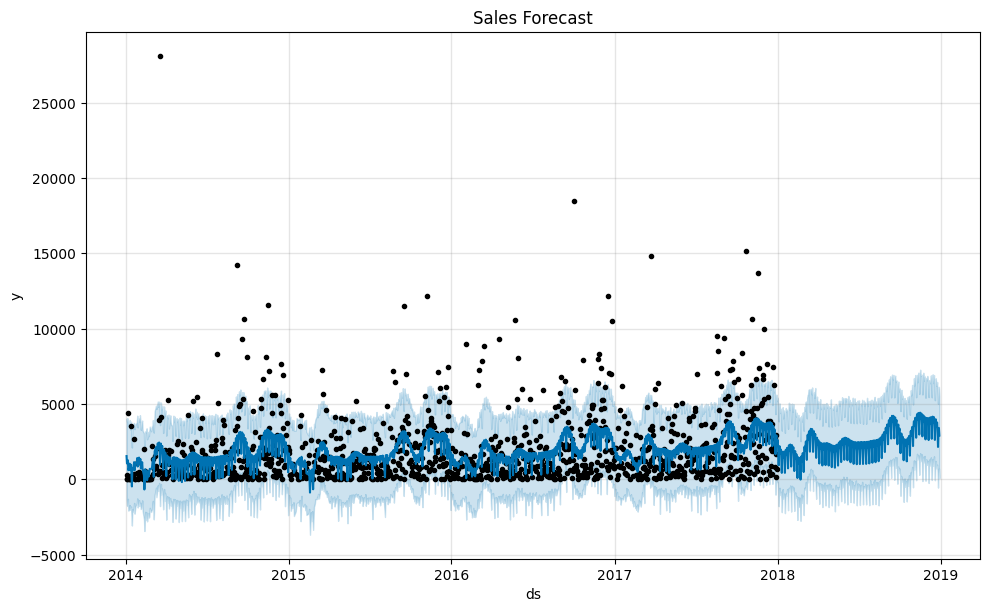

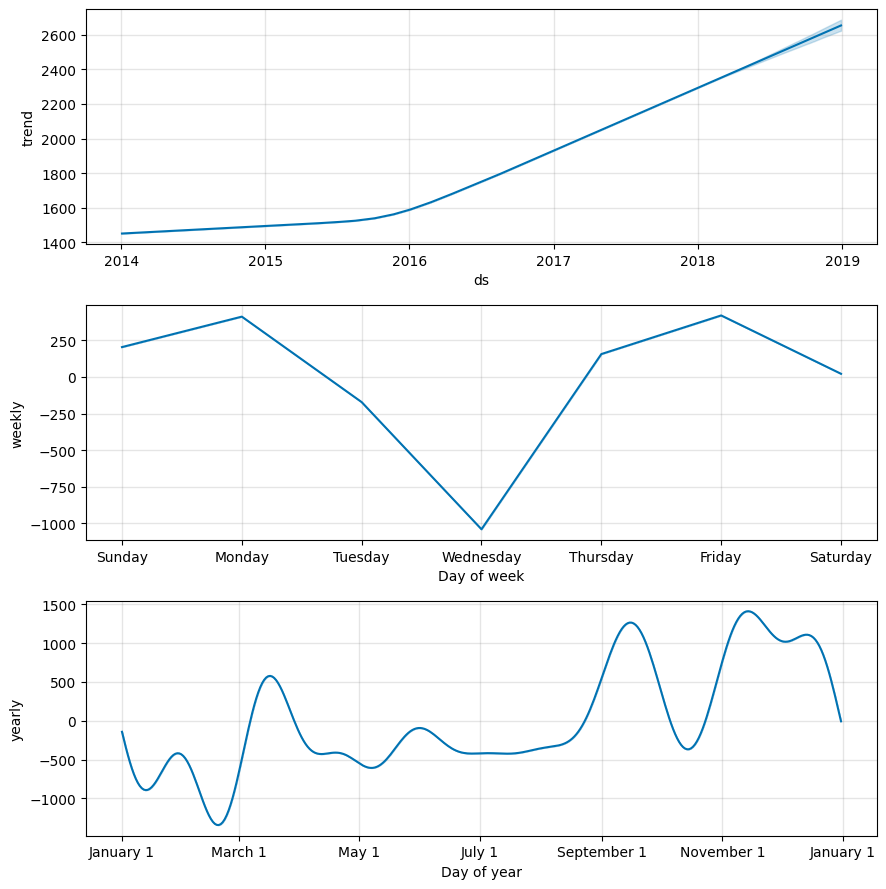

             ds         yhat  yhat_lower   yhat_upper
1596 2018-12-25  3112.483579  464.838773  5778.230232
1597 2018-12-26  2153.676295 -543.476446  5014.839616
1598 2018-12-27  3253.685778  414.023194  6023.807952
1599 2018-12-28  3416.078008  732.704720  6141.725336
1600 2018-12-29  2912.727064   94.881272  5509.036264


In [20]:
# aggregate sales by order date and get into Prophet format
prophet_df = sales_data.copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['Order Date'])
prophet_df = (
    prophet_df
    .groupby('ds', as_index=False)['Sales']
    .sum()
    .rename(columns={'Sales': 'y'})
)

# fit a Prophet model on the aggregated series
sales_model = Prophet()
sales_model.fit(prophet_df)

# make a future frame and forecast
future_sales = sales_model.make_future_dataframe(periods=364)   # e.g. 364‑day horizon
sales_forecast = sales_model.predict(future_sales)

# plot the forecast and its components
sales_model.plot(sales_forecast)
plt.title("Sales Forecast")
plt.show()

sales_model.plot_components(sales_forecast)
plt.show()

# review the last rows of the prediction
print(sales_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

## **Forecast for PROFIT Data**
- For the next 364 days

In [16]:
profit_data = df[['Profit','Order Date']].copy()

14:29:09 - cmdstanpy - INFO - Chain [1] start processing
14:29:10 - cmdstanpy - INFO - Chain [1] done processing


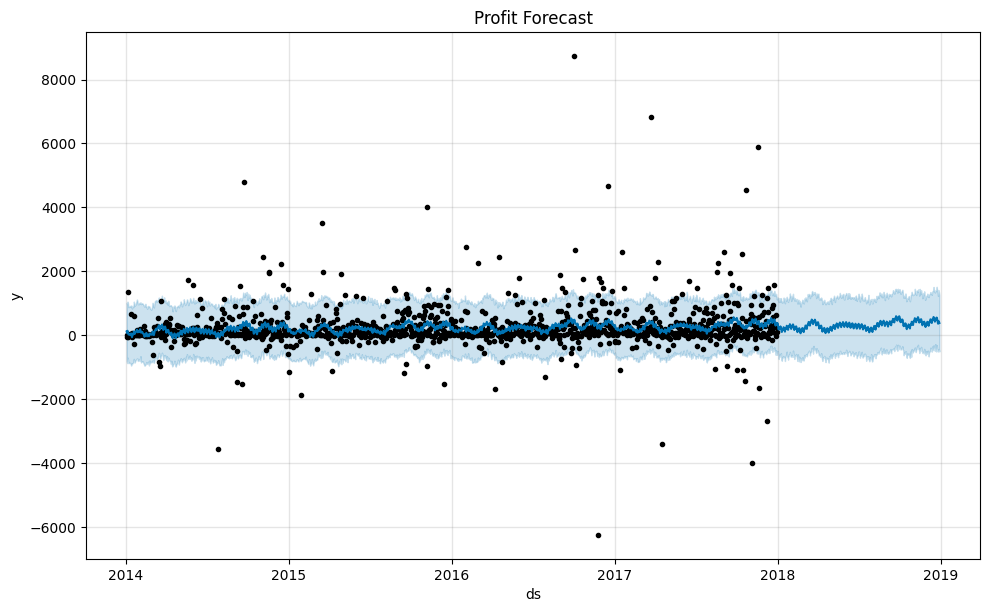

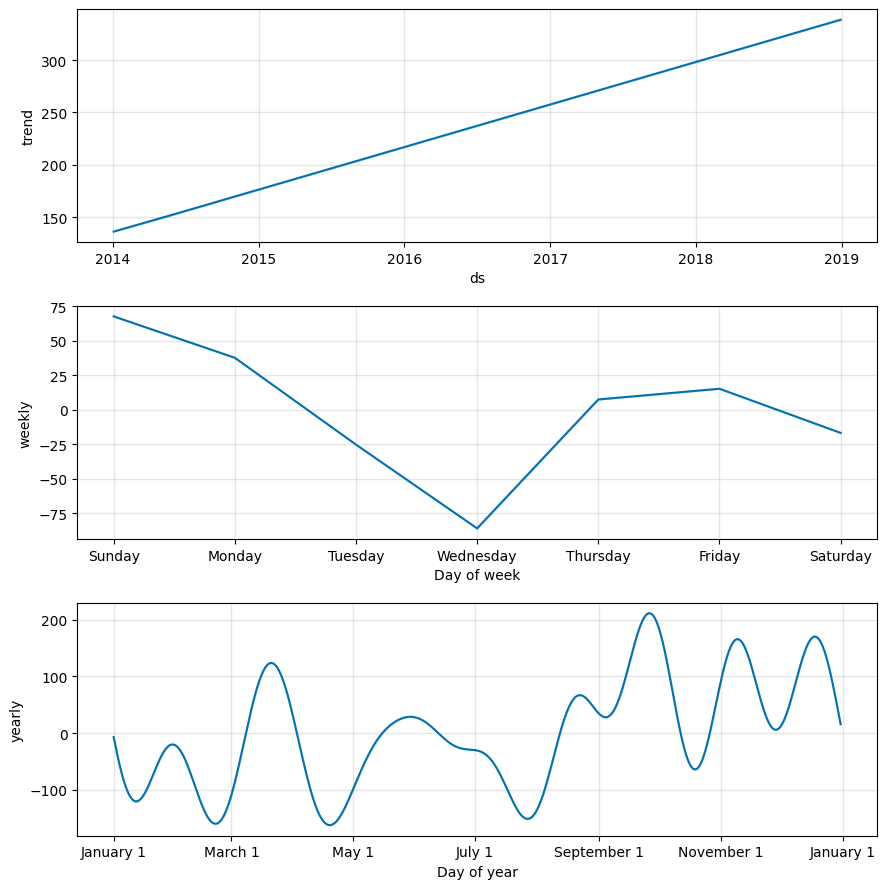

             ds        yhat  yhat_lower   yhat_upper
1596 2018-12-25  434.690248 -436.116112  1344.053579
1597 2018-12-26  359.640070 -513.234442  1228.816551
1598 2018-12-27  437.079845 -454.912664  1410.752506
1599 2018-12-28  427.973354 -448.726454  1355.604746
1600 2018-12-29  378.418698 -508.900179  1255.420140


In [19]:
# aggregate profit by order date and get into Prophet format
prophet_df = profit_data.copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['Order Date'])
prophet_df = (
    prophet_df
    .groupby('ds', as_index=False)['Profit']
    .sum()
    .rename(columns={'Profit': 'y'})
)

# fit a Prophet model on the aggregated series
profit_model = Prophet()
profit_model.fit(prophet_df)

# make a future frame and forecast
future_profit = profit_model.make_future_dataframe(periods=364)   # e.g. 364‑day horizon
profit_forecast = profit_model.predict(future_profit)

# plot the forecast and its components
profit_model.plot(profit_forecast)
plt.title("Profit Forecast")
plt.show()

profit_model.plot_components(profit_forecast)
plt.show()

# review the last rows of the prediction
print(profit_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

## **Forecast for Quantity Data**
- For the next 364 days

In [21]:
quantity_data = df[['Quantity','Order Date']].copy()

14:34:55 - cmdstanpy - INFO - Chain [1] start processing
14:35:20 - cmdstanpy - INFO - Chain [1] done processing


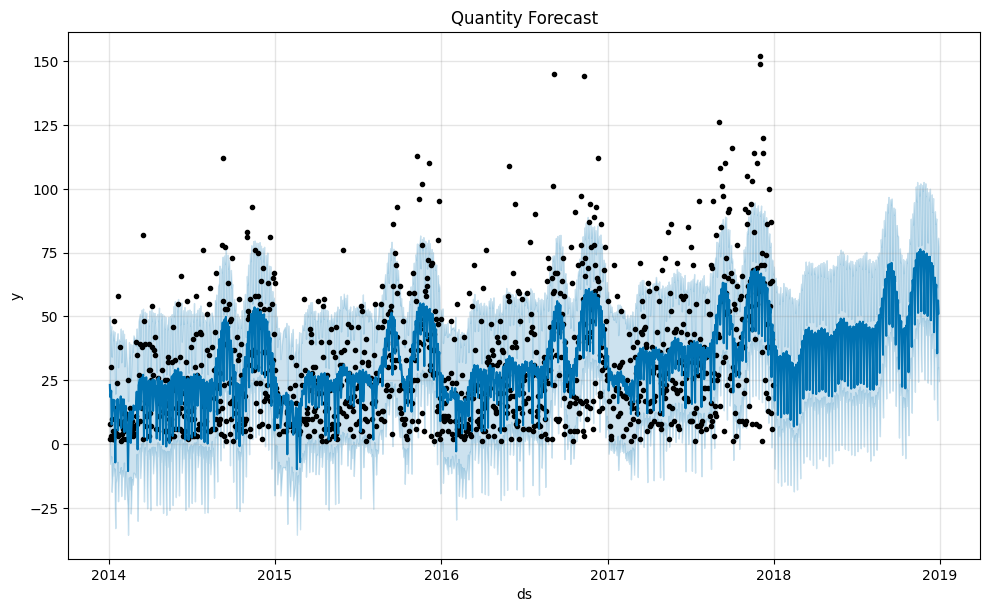

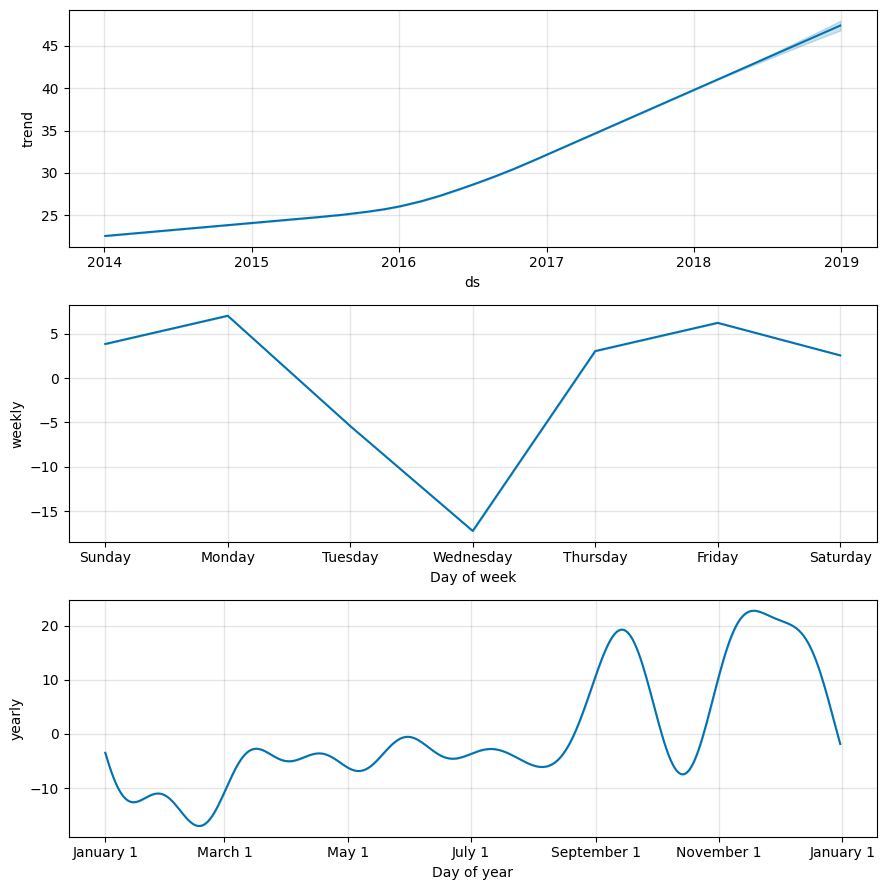

             ds       yhat  yhat_lower  yhat_upper
1596 2018-12-25  48.683959   24.707124   73.721506
1597 2018-12-26  35.543951    9.412582   61.326572
1598 2018-12-27  54.424580   28.997348   79.761734
1599 2018-12-28  56.224917   30.127430   80.786332
1600 2018-12-29  51.190597   24.602966   77.492600


In [22]:
# aggregate profit by order date and get into Prophet format
prophet_df = quantity_data.copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['Order Date'])
prophet_df = (
    prophet_df
    .groupby('ds', as_index=False)['Quantity']
    .sum()
    .rename(columns={'Quantity': 'y'})
)

# fit a Prophet model on the aggregated series
quantity_model = Prophet()
quantity_model.fit(prophet_df)

# make a future frame and forecast
future_quantity = quantity_model.make_future_dataframe(periods=364)   # e.g. 364‑day horizon
quantity_forecast = quantity_model.predict(future_quantity)

# plot the forecast and its components
quantity_model.plot(quantity_forecast)
plt.title("Quantity Forecast")
plt.show()

quantity_model.plot_components(quantity_forecast)
plt.show()

# review the last rows of the prediction
print(quantity_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())